In [117]:
%load_ext cuml.accel
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,VotingClassifier
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score,recall_score,roc_curve,auc,precision_score,precision_recall_curve
from itertools import product
import numpy as np

The cuml.accel extension is already loaded. To reload it, use:
  %reload_ext cuml.accel


In [118]:
def optimize_threshold(model, X_test, y_test, metric='f1'):
    """
    Finds and visualizes the optimal threshold for a binary classifier.
    """
    # 1. Get probability estimates for the positive class
    # Represented as the vector y_hat where y_hat_i = P(y=1 | x_i)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    # 2. Calculate precision-recall pairs for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    
    # 3. Optimize the chosen metric
    if metric == 'f1':
        # F1 = 2 * (P * R) / (P + R)
        scores = 2 * (precision * recall) / (precision + recall)
    else:
        raise ValueError("Metric not supported in this snippet. Use 'f1'.")
    
    # Ignore NaNs from division by zero
    scores = np.nan_to_num(scores)
    
    # Find the index of the maximum score
    # Note: precision_recall_curve returns 1 more value for P/R than thresholds
    best_idx = np.argmax(scores)
    best_threshold = thresholds[best_idx]
    
    # 4. Visualization
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precision[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recall[:-1], 'g-', label='Recall')
    plt.axvline(best_threshold, color='red', linestyle=':', label=f'Optimum: {best_threshold:.2f}')
    plt.xlabel('Threshold $\\tau$')
    plt.ylabel('Score')
    plt.title(f'Threshold Tuning (Optimizing {metric.upper()})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return best_threshold

In [119]:
def param_tunning(model_class, param_list, params_name,X_test,X_train,y_train,y_test,metric='f1',threshold=0.5):
    test_param = [list(p) for p in product(*param_list)]
    score = []
    best_score = 0
    best_estimator = None
    best_param = None
    
    for params in test_param:
        kwargs = dict(zip(params_name, params))
        model = model_class(**kwargs)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        if metric == 'recall':
            score = recall_score(y_test, y_pred)
        elif metric == 'f1':
            score = f1_score(y_test, y_pred)
        elif metric == 'accuracy_score':
            score = accuracy_score(y_test, y_pred)
        elif metric == 'presicion':
            score = precision_score(y_test,y_pred)
        else:
            raise ValueError("metric must be 'recall' or 'f1'")

        if score > best_score:
            best_score = score
            best_estimator = model
            best_param = kwargs

    print(f"Best params: {best_param}")
    print(f"Best {metric}: {best_score:.4f}")

    return best_estimator

In [120]:
def print_model_metrics(y_test, y_pred, model_name="Model"):
    """
    Calculates and prints Accuracy, Precision, Recall, and F1 Score.
    """
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"--- {model_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("-" * 30)

In [121]:
df = pd.read_csv('/media/vietnguyen/External HDD/football-ai-colab-/final/FinalData.csv')

In [122]:
df.head()
df = df.drop(columns='Unnamed: 0')

In [123]:
len(df[df['homeTeamWinner']==1])

155

In [124]:
len(df[df['homeTeamWinner']==0])

225

In [125]:
X = df.drop(columns='homeTeamWinner')
y = df['homeTeamWinner']

scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)
X_scaler = pd.DataFrame(X_scaler,columns=X.columns)
X_scaler.head()

,Min/Match_home,Min/Match_away,Clr/Match_home,Clr/Match_away,Blocks/Match_home,Blocks/Match_away,Int/Match_home,Int/Match_away,Age_home,Age_away,...,TklW%_diff,Rating_diff,PrgP_diff,DEF_diff,PrgR_diff,KP/Match_diff,npxG_diff,SoT%_diff,PrgC_diff,Sh/90_diff
0,-0.083751,-1.171374,-0.845533,-0.071760,-0.802572,-0.589548,1.337015,-0.003142,0.509672,1.351677,...,0.537038,0.169845,0.308117,0.262591,-0.481442,0.907831,-0.852202,0.034580,-0.357274,-0.545228
1,0.052732,0.338681,1.491027,-0.416442,1.490200,-0.583282,0.828942,0.114182,0.730141,0.114499,...,0.282690,-0.042072,-1.471119,0.768511,-2.087474,-0.803920,-2.326671,-0.187251,-0.357274,-0.883095
2,1.793012,0.097072,-1.169141,0.389046,-0.519196,1.672478,-0.483579,1.301230,-0.339122,0.836328,...,0.134608,0.200123,2.025388,-1.220981,1.802342,1.649962,1.154713,0.274375,1.988002,1.446557
3,-1.465660,-0.289643,0.240474,-0.864345,-0.963581,-0.489292,-0.497692,-0.334411,1.009402,0.234638,...,-1.104741,-1.295058,-1.842899,-0.074227,-0.887565,-1.609450,-0.388018,-0.094623,-2.306594,-0.125618
4,0.594413,0.137080,0.000967,0.685804,-0.293783,1.403040,-0.518862,0.555875,1.161209,-0.450410,...,-0.014249,0.453459,0.825954,-0.836989,2.092429,-0.240795,2.124039,0.282599,0.270164,1.120951


In [126]:
X_train,X_test,y_train,y_test = train_test_split(X_scaler,y,test_size=0.3,random_state=42)

In [127]:
params_name = ['n_estimators', 'max_depth', 'min_samples_leaf', 'max_features', 'criterion']

param_list = [
    [100, 300, 500],      # More trees are usually better but slower
    [10, 20, 30, None],   # Depth control
    [1, 2, 4],            # Leaf size
    ['sqrt', 'log2'],     # How many features to look at per split
    ['gini', 'entropy']   # Splitting criterion
]

# 3. Call your function
# Make sure you pass your top 15 features as X_train/X_test
best_rf = param_tunning(
    RandomForestClassifier, 
    param_list, 
    params_name, 
    X_test, 
    X_train, 
    y_train, 
    y_test, 
    metric='accuracy_score'
)

Best params: {'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 'log2', 'criterion': 'entropy'}
Best accuracy_score: 0.6404


In [128]:
# 1. Define the parameter names
params_name = ['n_estimators', 'learning_rate']
# 2. Define the values for each parameter
# n_estimators: Number of weak learners to train iteratively.
# learning_rate: Weight applied to each classifier at each boosting iteration.
# algorithm: 'SAMME' (discrete) or 'SAMME.R' (real/probability-based).
param_list = [
    [50, 100, 200, 500],       # n_estimators
    [0.01, 0.1, 0.5, 1.0]     # learning_rate
]

# 3. Call your function
best_ada = param_tunning(
    model_class=AdaBoostClassifier,
    param_list=param_list,
    params_name=params_name,
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test,
    metric='accuracy_score',
    threshold=0.5
)

Best params: {'n_estimators': 50, 'learning_rate': 1.0}
Best accuracy_score: 0.6053


In [129]:
params_name = ['n_neighbors', 'weights', 'p']

# 2. Define values
# n_neighbors: The 'k' in KNN. Odd numbers prevent ties in binary classification.
# weights: 'uniform' (all neighbors equal) vs 'distance' (closer neighbors vote stronger).
# p: Power parameter for the Minkowski metric. 1 = Manhattan, 2 = Euclidean.
n_neighbors = range(1,21)
param_list = [
    n_neighbors,  # n_neighbors
    ['uniform', 'distance'],   # weights
    [1, 2]                     # p
]

# 3. Call your function
best_knn = param_tunning(
    model_class=KNeighborsClassifier,
    param_list=param_list,
    params_name=params_name,
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test,
    metric='accuracy_score'
)


Best params: {'n_neighbors': 17, 'weights': 'distance', 'p': 2}
Best accuracy_score: 0.7281


In [130]:
y_predict_knn = best_knn.predict(X_test)
y_preidct_proba_knn = best_knn.predict_proba(X_test)

In [131]:
y_predict_ada = best_ada.predict(X_test)
y_preidct_proba_ada = best_ada.predict_proba(X_test)

In [132]:
y_predict_rf = best_rf.predict(X_test)
y_preidct_proba_rf = best_rf.predict_proba(X_test)

In [133]:
accuracy_score_rf = accuracy_score(y_test,y_predict_rf)
print(f"Acuracy score of RandomForestClassifier: {accuracy_score_rf}")
accuracy_score_ada = accuracy_score(y_test,y_predict_ada)
print(f"Acuracy score of Ada: {accuracy_score_ada}")
accuracy_score_knn = accuracy_score(y_test,y_predict_knn)
print(f"Acuracy score of KNN: {accuracy_score_knn}")


Acuracy score of RandomForestClassifier: 0.6403508771929824
Acuracy score of Ada: 0.6052631578947368
Acuracy score of KNN: 0.7280701754385965


In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

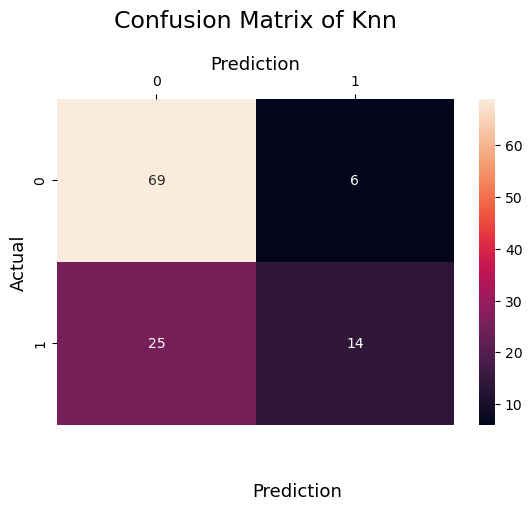

In [135]:
confusion_matrix_knn = confusion_matrix(y_test,y_predict_knn)
sns.heatmap(confusion_matrix_knn, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of Knn', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

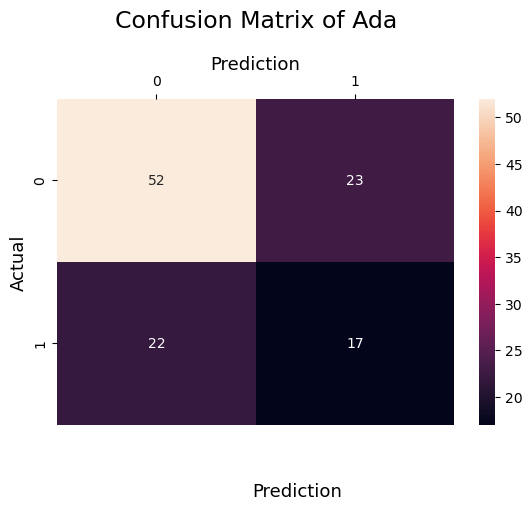

In [136]:
confusion_matrix_ada = confusion_matrix(y_test,y_predict_ada)
sns.heatmap(confusion_matrix_ada, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of Ada', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

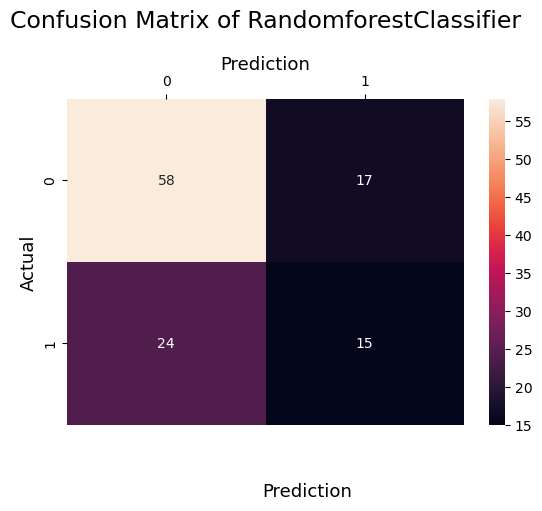

In [137]:
confusion_matrix_rf = confusion_matrix(y_test,y_predict_rf)
sns.heatmap(confusion_matrix_rf, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of RandomforestClassifier', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

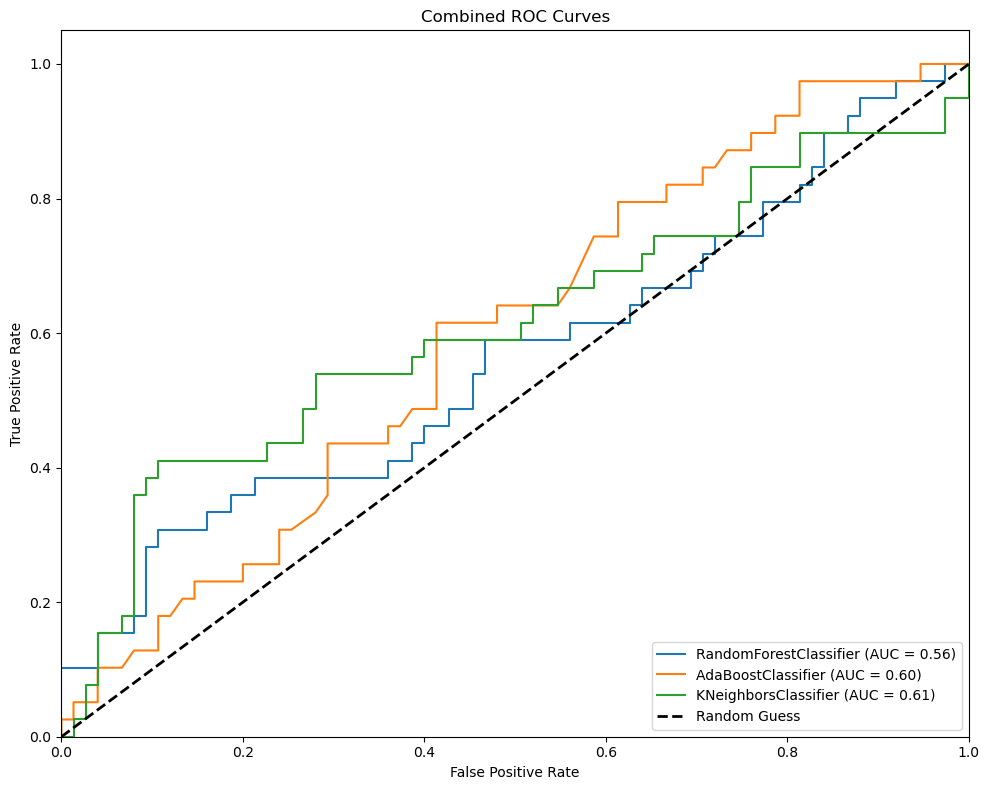

In [138]:
def plot_roc_curve(model_name, y_true, y_prob, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot the curve
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    
    # We set these labels every time, which is fine (they are the same)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    
    # IMPORTANT: Use set_title, not title
    # We will set a generic title outside the function for the combined plot
    
    ax.legend(loc="lower right")
    
    return ax

# 2. Setup the single plot
plt.figure(figsize=(10, 8))
ax = plt.gca()  # Get the current axes

# 3. Plot ROC curves for each model on the SAME 'ax'
plot_roc_curve("RandomForestClassifier", y_test, y_preidct_proba_rf[:, 1], ax=ax)
plot_roc_curve("AdaBoostClassifier", y_test, y_preidct_proba_ada[:, 1], ax=ax)
plot_roc_curve("KNeighborsClassifier", y_test, y_preidct_proba_knn[:, 1], ax=ax)

# 4. Final touches for the combined plot
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess') # Add diagonal random guess line
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_title('Combined ROC Curves')
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [139]:
print("--- Bagging of Ada report ---")
print(print_model_metrics(y_test, y_predict_ada))
print("--- Bagging of Rf report ---")
print(print_model_metrics(y_test, y_predict_rf))

--- Bagging of Ada report ---
--- Model Performance ---
Accuracy:  0.6053
Precision: 0.4250
Recall:    0.4359
F1 Score:  0.4304
------------------------------
None
--- Bagging of Rf report ---
--- Model Performance ---
Accuracy:  0.6404
Precision: 0.4688
Recall:    0.3846
F1 Score:  0.4225
------------------------------
None


In [140]:
print("--- Bagging of KNN report ---")
print(print_model_metrics(y_test, y_predict_knn))

--- Bagging of KNN report ---
--- Model Performance ---
Accuracy:  0.7281
Precision: 0.7000
Recall:    0.3590
F1 Score:  0.4746
------------------------------
None


In [141]:
base_classifier = best_knn
bagging_classifier = BaggingClassifier(base_classifier, n_estimators=10, random_state=42)
bagging_classifier.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",KNeighborsCla...ts='distance')
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [142]:
y_predict_bag_knn = bagging_classifier.predict(X_test)
y_preidct_proba_bag_knn = bagging_classifier.predict_proba(X_test)

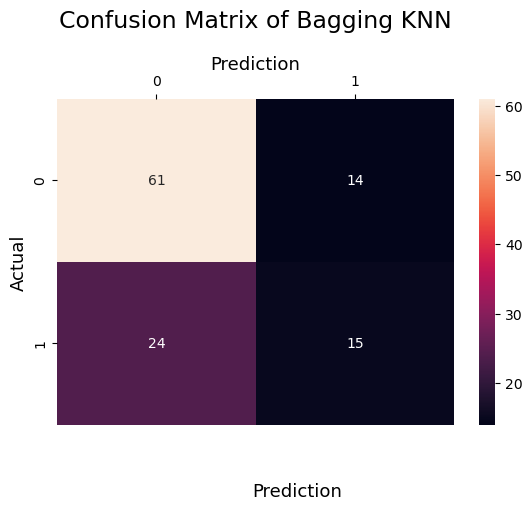

In [143]:
confusion_matrix_bag_knn = confusion_matrix(y_test,y_predict_bag_knn)
sns.heatmap(confusion_matrix_bag_knn, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of Bagging KNN', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

In [144]:
print("--- Bagging of KNN report ---")
print(print_model_metrics(y_test, y_predict_bag_knn))

--- Bagging of KNN report ---
--- Model Performance ---
Accuracy:  0.6667
Precision: 0.5172
Recall:    0.3846
F1 Score:  0.4412
------------------------------
None


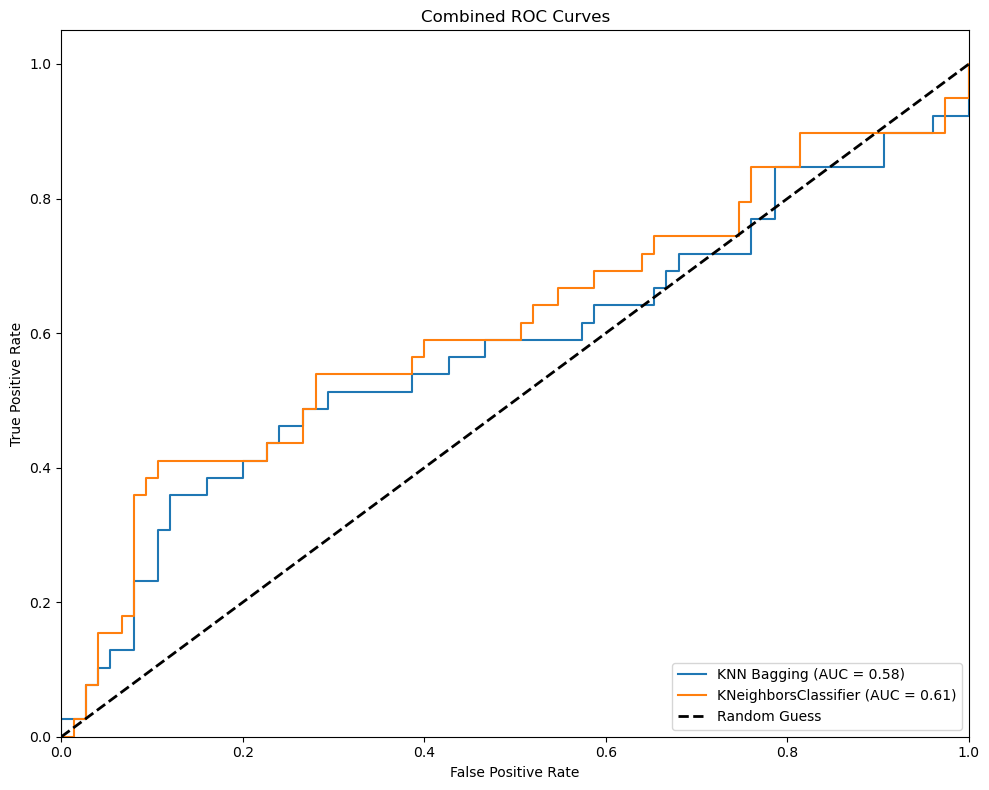

In [145]:


# 2. Setup the single plot
plt.figure(figsize=(10, 8))
ax = plt.gca()  # Get the current axes

# 3. Plot ROC curves for each model on the SAME 'ax'
plot_roc_curve("KNN Bagging", y_test, y_preidct_proba_bag_knn[:, 1], ax=ax)

plot_roc_curve("KNeighborsClassifier", y_test, y_preidct_proba_knn[:, 1], ax=ax)

# 4. Final touches for the combined plot
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess') # Add diagonal random guess line
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_title('Combined ROC Curves')
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [146]:
param_list = [
    [0.001, 0.01, 0.1, 1, 10, 100],  # C (usually logarithmic scale)
    ['liblinear', 'lbfgs']           # solver ('liblinear' is good for small data, 'lbfgs' is default)
]

params_name = ['C', 'solver']

# 3. Call your function
best_log = param_tunning(
    model_class=LogisticRegression,
    param_list=param_list,
    params_name=params_name,
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test,
    metric='presicion',
    threshold=0.5
)

Best params: {'C': 10, 'solver': 'liblinear'}
Best presicion: 0.5333


In [147]:
estimator = [
    ("LogisticRegression",LogisticRegression(C=10,solver='liblinear')),
    ('KNeighborsClassifier',KNeighborsClassifier(n_neighbors=17,weights='distance',p=2))
]

In [148]:
vote_model = VotingClassifier(estimators=estimator,voting='soft')
vote_model.fit(X_train,y_train)

y_predict_vote = vote_model.predict(X_test)
y_preidct_proba_vote_model = vote_model.predict_proba(X_test)

In [149]:
print("--- Voting ensemble (Logistic,KNN) report ---")
print(print_model_metrics(y_test, y_predict_vote))

--- Voting ensemble (Logistic,KNN) report ---
--- Model Performance ---
Accuracy:  0.7018
Precision: 0.6087
Recall:    0.3590
F1 Score:  0.4516
------------------------------
None


In [150]:
from xgboost import XGBClassifier


In [151]:
params_name = ['n_estimators', 'learning_rate', 'max_depth']

# 2. Define the values for each parameter
param_list = [
    [50, 100, 200],          # n_estimators: How many trees to build
    [0.01, 0.1, 0.2],        # learning_rate: Speed of learning (lower is usually better but slower)
    [3, 4, 5]                # max_depth: Limit tree complexity. Small data needs small depth (3-5).
]

# 3. Call your function
# Note: eval_metric='logloss' avoids warnings in newer XGBoost versions
model_xgb = param_tunning(
    model_class=XGBClassifier,
    param_list=param_list,
    params_name=params_name,
    X_train=X_train, 
    X_test=X_test, 
    y_train=y_train, 
    y_test=y_test,
    metric='presicion',
    threshold=0.5,
)

Best params: {'n_estimators': 200, 'learning_rate': 0.2, 'max_depth': 3}
Best presicion: 0.4444


In [152]:
y_predict_xgb= model_xgb.predict(X_test)
y_preidct_proba_xgb = model_xgb.predict_proba(X_test)

In [153]:
print("--- XGB report ---")
print(print_model_metrics(y_test, y_predict_xgb))

--- XGB report ---
--- Model Performance ---
Accuracy:  0.6140
Precision: 0.4444
Recall:    0.5128
F1 Score:  0.4762
------------------------------
None


In [154]:
estimator = [
    ("LogisticRegression",LogisticRegression(C=10,solver='liblinear')),
    #('KNeighborsClassifier',KNeighborsClassifier(n_neighbors=17,weights='distance',p=2)),
    ('XGB',XGBClassifier())
]

In [155]:
vote_model = VotingClassifier(estimators=estimator,voting='soft')
vote_model.fit(X_train,y_train)

y_predict_vote = vote_model.predict(X_test)
y_preidct_proba_vote_model = vote_model.predict_proba(X_test)

In [156]:
print("--- Voting ensemble (Logistic,KNN) report ---")
print(print_model_metrics(y_test, y_predict_vote))

--- Voting ensemble (Logistic,KNN) report ---
--- Model Performance ---
Accuracy:  0.6404
Precision: 0.4706
Recall:    0.4103
F1 Score:  0.4384
------------------------------
None


In [157]:
from sklearn.decomposition import PCA

# Giữ lại 95% thông tin quan trọng, loại bỏ nhiễu
pca = PCA(n_components=20) 
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train KNN trên dữ liệu PCA này

In [158]:
params_name = ['n_neighbors', 'weights', 'p']

# 2. Define values
# n_neighbors: The 'k' in KNN. Odd numbers prevent ties in binary classification.
# weights: 'uniform' (all neighbors equal) vs 'distance' (closer neighbors vote stronger).
# p: Power parameter for the Minkowski metric. 1 = Manhattan, 2 = Euclidean.
n_neighbors = range(1,21)
param_list = [
    n_neighbors,  # n_neighbors
    ['uniform', 'distance'],   # weights
    [1, 2]                     # p
]

# 3. Call your function
best_knn = param_tunning(
    model_class=KNeighborsClassifier,
    param_list=param_list,
    params_name=params_name,
    X_train=X_train_pca, 
    X_test=X_test_pca, 
    y_train=y_train, 
    y_test=y_test,
    metric='presicion'
)

Best params: {'n_neighbors': 17, 'weights': 'uniform', 'p': 2}
Best presicion: 0.6842


In [159]:
y_predict_knn = best_knn.predict(X_test_pca)
y_preidct_proba_knn = best_knn.predict_proba(X_test_pca)

In [160]:
print("--- KNN Pca report ---")
print(print_model_metrics(y_test, y_predict_knn))

--- KNN Pca report ---
--- Model Performance ---
Accuracy:  0.7193
Precision: 0.6842
Recall:    0.3333
F1 Score:  0.4483
------------------------------
None


In [161]:
df.columns

Index(['homeTeamWinner', 'Min/Match_home', 'Min/Match_away', 'Clr/Match_home',
       'Clr/Match_away', 'Blocks/Match_home', 'Blocks/Match_away',
       'Int/Match_home', 'Int/Match_away', 'Age_home', 'Age_away',
       'TklW%_home', 'TklW%_away', 'Rating_home', 'Rating_away', 'PrgP_home',
       'PrgP_away', 'DEF_home', 'DEF_away', 'PrgR_home', 'PrgR_away',
       'KP/Match_home', 'KP/Match_away', 'npxG_home', 'npxG_away', 'SoT%_home',
       'SoT%_away', 'PrgC_home', 'PrgC_away', 'Sh/90_home', 'Sh/90_away',
       'Min/Match_diff', 'Clr/Match_diff', 'Blocks/Match_diff',
       'Int/Match_diff', 'Age_diff', 'TklW%_diff', 'Rating_diff', 'PrgP_diff',
       'DEF_diff', 'PrgR_diff', 'KP/Match_diff', 'npxG_diff', 'SoT%_diff',
       'PrgC_diff', 'Sh/90_diff'],
      dtype='object')

In [162]:
drop_feature = ['Min/Match_home', 'Min/Match_away', 'Clr/Match_home',
       'Clr/Match_away', 'Blocks/Match_home', 'Blocks/Match_away',
       'Int/Match_home', 'Int/Match_away', 'Age_home', 'Age_away',
       'TklW%_home', 'TklW%_away', 'Rating_home', 'Rating_away', 'PrgP_home',
       'PrgP_away', 'DEF_home', 'DEF_away', 'PrgR_home', 'PrgR_away',
       'KP/Match_home', 'KP/Match_away', 'npxG_home', 'npxG_away', 'SoT%_home',
       'SoT%_away', 'PrgC_home', 'PrgC_away', 'Sh/90_home', 'Sh/90_away']

df_diff_feature = df.drop(columns=drop_feature,axis=1)

In [163]:
X_new = df_diff_feature.drop(columns='homeTeamWinner',axis=1)
y_new = df_diff_feature['homeTeamWinner']

X_train_new,X_test_new,y_train_new,y_test_new = train_test_split(X_new,y_new,test_size=0.2,random_state=42)

In [164]:
params_name = ['n_neighbors', 'weights', 'p']

# 2. Define values
# n_neighbors: The 'k' in KNN. Odd numbers prevent ties in binary classification.
# weights: 'uniform' (all neighbors equal) vs 'distance' (closer neighbors vote stronger).
# p: Power parameter for the Minkowski metric. 1 = Manhattan, 2 = Euclidean.
n_neighbors = range(3,21)
param_list = [
    n_neighbors,  # n_neighbors
    ['uniform', 'distance'],   # weights
    [1, 2]                     # p
]

# 3. Call your function
best_knn_new = param_tunning(
    model_class=KNeighborsClassifier,
    param_list=param_list,
    params_name=params_name,
    X_train=X_train_new, 
    X_test=X_test_new, 
    y_train=y_train_new, 
    y_test=y_test_new,
    metric='presicion'
)

Best params: {'n_neighbors': 6, 'weights': 'distance', 'p': 2}
Best presicion: 0.4615


In [165]:
y_predict_knn_new = best_knn_new.predict(X_test_new)
y_predict_proba_knn_new = best_knn_new.predict_proba(X_test_new)

In [166]:
print_model_metrics(y_test_new,y_predict_knn_new,model_name='KNN with less feature')

--- KNN with less feature Performance ---
Accuracy:  0.6316
Precision: 0.4615
Recall:    0.4615
F1 Score:  0.4615
------------------------------


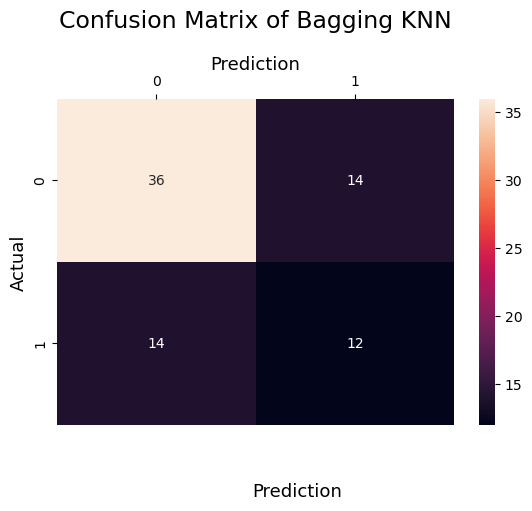

In [167]:
cfs_knn_new = confusion_matrix(y_test_new,y_predict_knn_new)
sns.heatmap(cfs_knn_new, 
            annot=True,
            fmt='g', 
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix of Bagging KNN', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

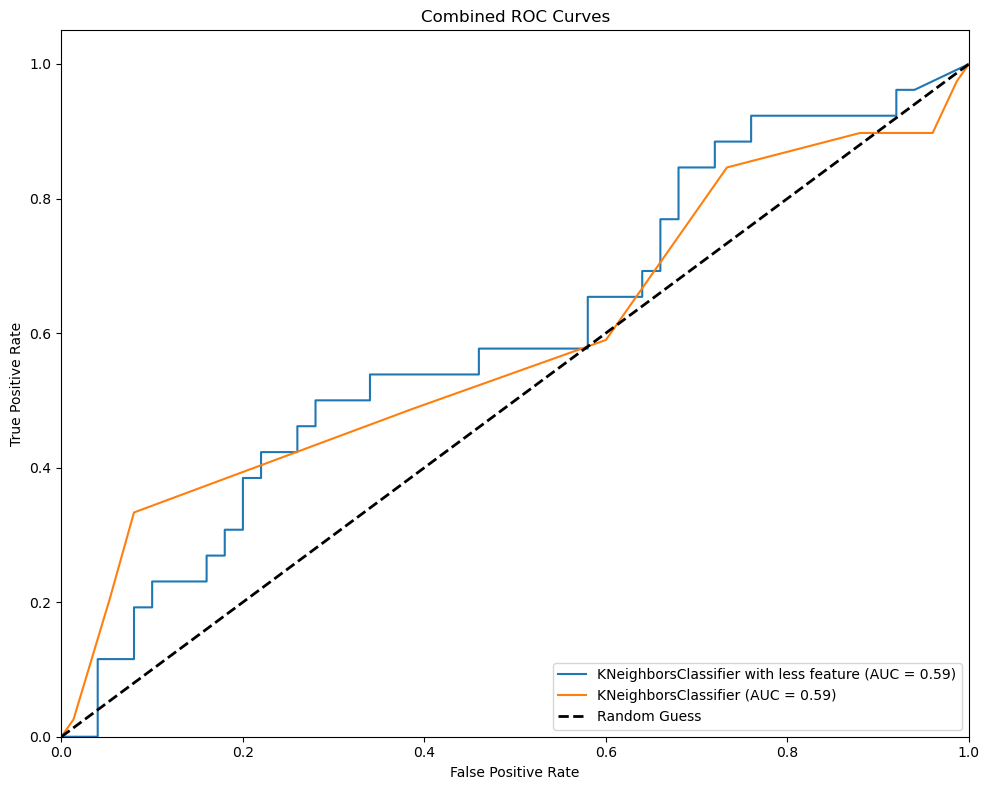

In [168]:
plt.figure(figsize=(10, 8))
ax = plt.gca()  # Get the current axes

# 3. Plot ROC curves for each model on the SAME 'ax'
plot_roc_curve("KNeighborsClassifier with less feature", y_test_new, y_predict_proba_knn_new[:, 1], ax=ax)
plot_roc_curve("KNeighborsClassifier", y_test, y_preidct_proba_knn[:, 1], ax=ax)

# 4. Final touches for the combined plot
ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess') # Add diagonal random guess line
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_title('Combined ROC Curves')
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [169]:
precision = [precision_score(y_test,y_predict_knn),precision_score(y_test_new,y_predict_knn_new)]
recall = [recall_score(y_test,y_predict_knn),recall_score(y_test_new,y_predict_knn_new)]
f1 = [f1_score(y_test,y_predict_knn),f1_score(y_test_new,y_predict_knn_new)]
accuracy = [accuracy_score(y_test,y_predict_knn),accuracy_score(y_test_new,y_predict_knn_new)]
categories = ['Knn','Knn_new']

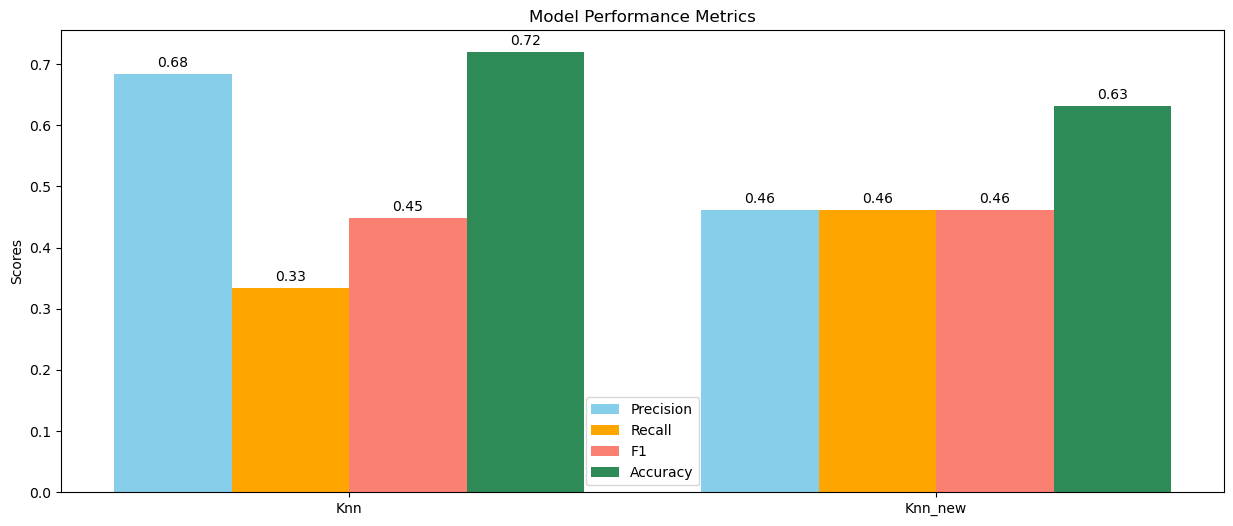

In [170]:
x = np.arange(len(categories))  
width = 0.2  

fig, ax = plt.subplots(figsize=(15, 6))

rects1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='orange')
rects3 = ax.bar(x + 0.5*width, f1,        width, label='F1',        color='salmon')
rects4 = ax.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color='seagreen')

ax.bar_label(rects1, padding=3, fmt='%.2f') 
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.show()

In [171]:
from imblearn.over_sampling import SMOTE

In [172]:
sm = SMOTE(random_state=42)

X_train_res,y_train_res = sm.fit_resample(X_train,y_train)

In [173]:
model_knn_sm = KNeighborsClassifier(n_neighbors=17, weights='uniform', p=2)
model_knn_sm.fit(X_train_res, y_train_res)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",17
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [174]:
y_predict_smote_knn = model_knn_sm.predict(X_test)

precision = [precision_score(y_test,y_predict_knn),precision_score(y_test,y_predict_smote_knn)]
recall = [recall_score(y_test,y_predict_knn),recall_score(y_test,y_predict_smote_knn)]
f1 = [f1_score(y_test,y_predict_knn),f1_score(y_test,y_predict_smote_knn)]
accuracy = [accuracy_score(y_test,y_predict_knn),accuracy_score(y_test,y_predict_smote_knn)]
categories = ['Knn','Knn SMOTE']

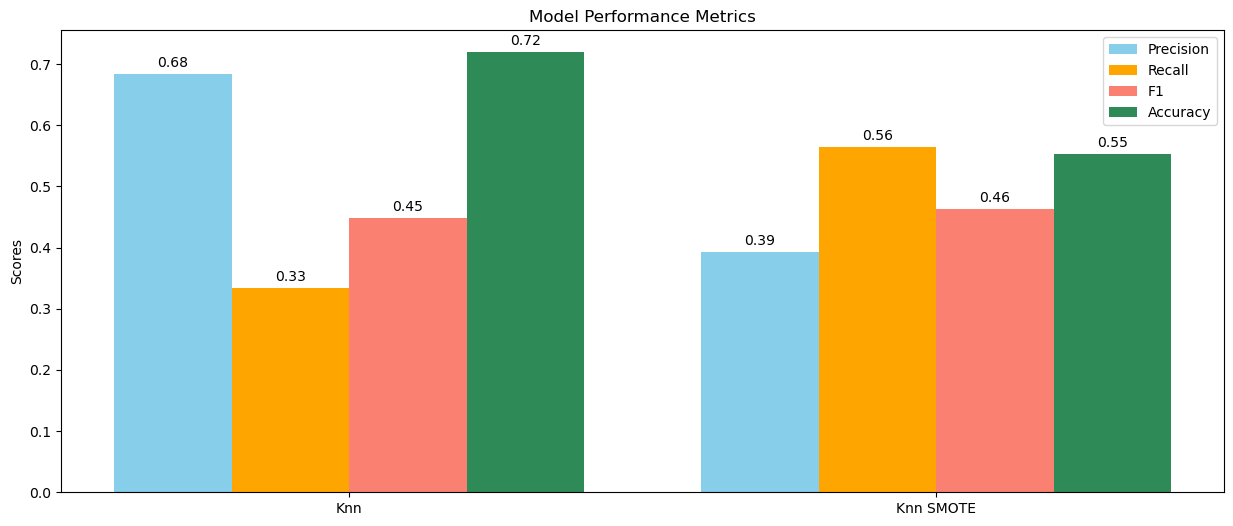

In [175]:
x = np.arange(len(categories))  
width = 0.2  
fig, ax = plt.subplots(figsize=(15, 6))

rects1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='orange')
rects3 = ax.bar(x + 0.5*width, f1,        width, label='F1',        color='salmon')
rects4 = ax.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color='seagreen')

ax.bar_label(rects1, padding=3, fmt='%.2f') 
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.show()

In [176]:
def find_best_thres(y_test,y_pred,model_name):
    fpr,tpr,threshold = roc_curve(y_test,y_pred)

    j = tpr-fpr
    idmax = np.argmax(j)
    best_threshold = threshold[idmax]

    print(f"Best threshold for {model_name}: {best_threshold}")
    return best_threshold

In [177]:
best_thres_knn = find_best_thres(y_test=y_test,y_pred=y_preidct_proba_knn[:,1],model_name='KNN')

y_predict_knn_thresTun = (y_preidct_proba_knn[:,1] > best_thres_knn).astype(int)

Best threshold for KNN: 0.529411792755127


In [178]:
y_predict_smote_knn = model_knn_sm.predict(X_test)

precision = [precision_score(y_test,y_predict_knn),precision_score(y_test,y_predict_knn_thresTun)]
recall = [recall_score(y_test,y_predict_knn),recall_score(y_test,y_predict_knn_thresTun)]
f1 = [f1_score(y_test,y_predict_knn),f1_score(y_test,y_predict_knn_thresTun)]
accuracy = [accuracy_score(y_test,y_predict_knn),accuracy_score(y_test,y_predict_knn_thresTun)]
categories = ['Knn','Knn Thres Tunning']

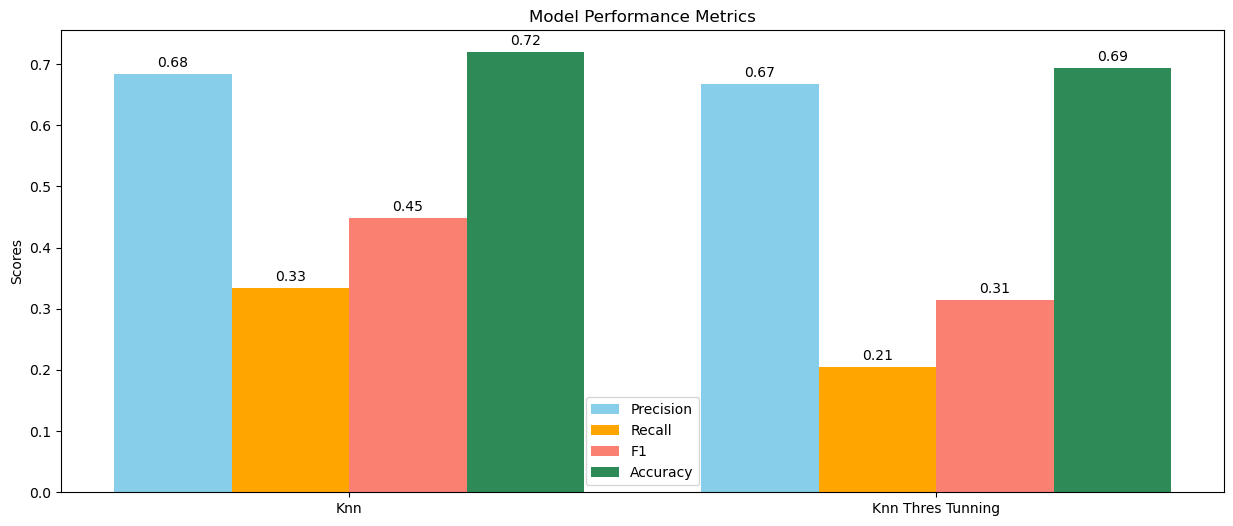

In [179]:
x = np.arange(len(categories))  
width = 0.2  
fig, ax = plt.subplots(figsize=(15, 6))

rects1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='orange')
rects3 = ax.bar(x + 0.5*width, f1,        width, label='F1',        color='salmon')
rects4 = ax.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color='seagreen')

ax.bar_label(rects1, padding=3, fmt='%.2f') 
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.show()

In [180]:
from joblib import dump

In [181]:
dump(best_knn,'MatchResultpredictModel.joblib')

['MatchResultpredictModel.joblib']

In [182]:
from sklearn.metrics import precision_recall_curve

In [183]:
precision,recall,threshold = precision_recall_curve(y_test,y_predict_knn)


f1_score = (2 * precision * recall ) / (precision + recall)
idmax = np.argmax(f1_score)


best_threshold_prc = threshold[idmax]
print(f"Best threshold by precision recal curve for knn: {best_threshold_prc}")

Best threshold by precision recal curve for knn: 0


In [184]:
y_predict_knn_thres_tunPRC = (y_preidct_proba_knn[:,1] > best_threshold_prc).astype(int)

In [185]:
y_predict_smote_knn = model_knn_sm.predict(X_test)

precision = [precision_score(y_test,y_predict_knn),precision_score(y_test,y_predict_knn_thres_tunPRC)]
recall = [recall_score(y_test,y_predict_knn),recall_score(y_test,y_predict_knn_thres_tunPRC)]
#f1 = [f1_score(y_test,y_predict_knn),f1_score(y_test,y_predict_knn_thres_tunPRC)]
accuracy = [accuracy_score(y_test,y_predict_knn),accuracy_score(y_test,y_predict_knn_thres_tunPRC)]
categories = ['Knn','Knn Thres Tunning by prc']

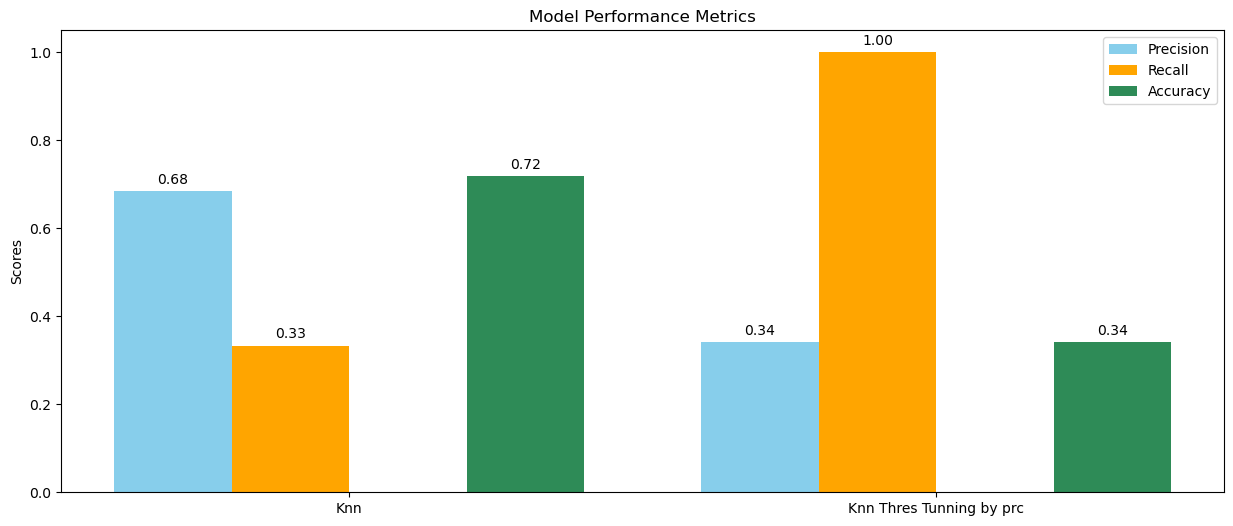

In [186]:
x = np.arange(len(categories))  
width = 0.2  
fig, ax = plt.subplots(figsize=(15, 6))

rects1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='orange')
#rects3 = ax.bar(x + 0.5*width, f1,        width, label='F1',        color='salmon')
rects4 = ax.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color='seagreen')

ax.bar_label(rects1, padding=3, fmt='%.2f') 
ax.bar_label(rects2, padding=3, fmt='%.2f')
#ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.show()

In [195]:
precision=[]
threshold_pre=np.arange(0.1,1,0.00001)
for i in np.arange(0.1,1,0.00001):
    y_pred = (y_preidct_proba_knn[:,1] > i).astype(int)
    precision.append(precision_score(y_test,y_pred,zero_division=0))

idxmax = np.argmax(precision)
best_thres_loop_pre = threshold_pre[idxmax]



print(f"Best threshold by loop tun for precision: {best_thres_loop_pre}")

Best threshold by loop tun for precision: 0.4705899999998563


In [196]:
y_predict_knn_thresLoop = (y_preidct_proba_knn[:,1] > best_thres_loop_pre).astype(int)

precision = [precision_score(y_test,y_predict_knn),precision_score(y_test,y_predict_knn_thresLoop)]
recall = [recall_score(y_test,y_predict_knn),recall_score(y_test,y_predict_knn_thresLoop)]
#f1 = [f1_score(y_test,y_predict_knn),f1_score(y_test,y_predict_knn_thresLoop)]
accuracy = [accuracy_score(y_test,y_predict_knn),accuracy_score(y_test,y_predict_knn_thresLoop)]
categories = ['Knn','Knn Thres Tunning by loop']

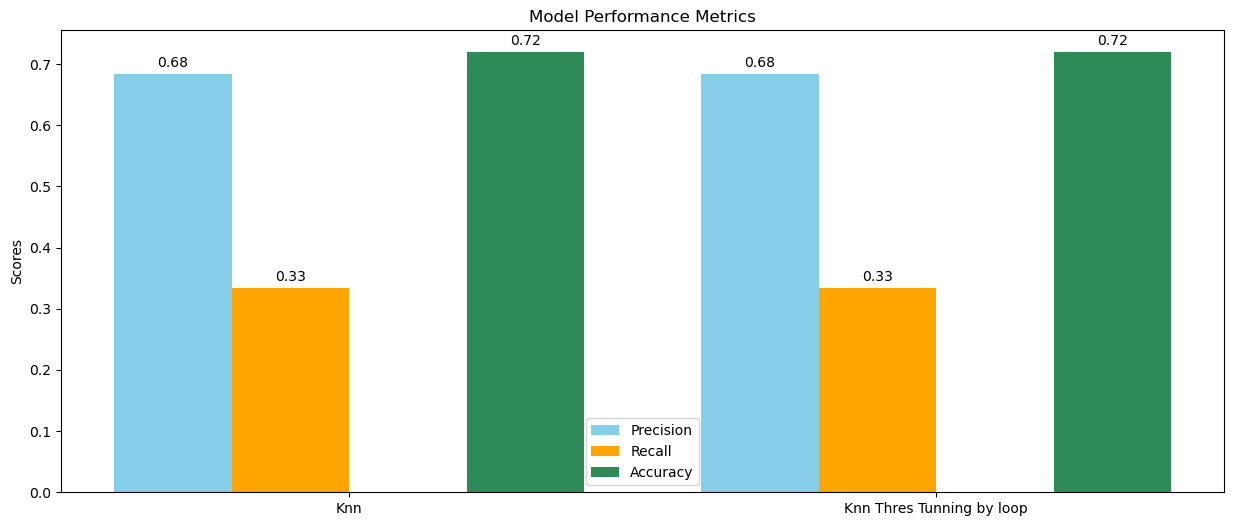

In [199]:
x = np.arange(len(categories))  
width = 0.2  
fig, ax = plt.subplots(figsize=(15, 6))

rects1 = ax.bar(x - 1.5*width, precision, width, label='Precision', color='skyblue')
rects2 = ax.bar(x - 0.5*width, recall,    width, label='Recall',    color='orange')
#rects3 = ax.bar(x + 0.5*width, f1,        width, label='F1',        color='salmon')
rects4 = ax.bar(x + 1.5*width, accuracy,  width, label='Accuracy',  color='seagreen')

ax.bar_label(rects1, padding=3, fmt='%.2f') 
ax.bar_label(rects2, padding=3, fmt='%.2f')
#ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

plt.show()